<a href="https://colab.research.google.com/github/Akash9888/thesis_code/blob/master/KG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import networkx as nx
import pickle
from google.colab import drive
import matplotlib.pyplot as plt
import networkx as nx



drive.mount('/content/drive')
FILE_PATH = '/content/drive/MyDrive/ThesisData/MASTER_THESIS_DATA.csv'
df = pd.read_csv(FILE_PATH)


G = nx.DiGraph()
edges = []

print("Building Global Knowledge Graph...")


for idx, row in df.iterrows():
    ticker = row['Ticker']
    entities = str(row['entities'])
    sentiment = row['sentiment_score']

    if 'FDA' in entities:
        edges.append(('FDA', ticker, {'weight': sentiment, 'type': 'Regulator'}))

    if 'Trump' in entities:
        edges.append(('Trump', ticker, {'weight': sentiment, 'type': 'Influencer'}))

    if 'Brexit' in entities:
        edges.append(('Brexit', ticker, {'weight': sentiment, 'type': 'Event'}))

    if 'Medicare' in entities or 'Obamacare' in entities:
        edges.append(('Policy_Shock', ticker, {'weight': sentiment, 'type': 'Policy'}))

G.add_edges_from(edges)


nx.set_node_attributes(G, {n: 'Asset' for n in df['Ticker'].unique()}, 'type')

hub_types = {'FDA': 'Regulator', 'Trump': 'Influencer', 'Brexit': 'Event', 'Policy_Shock': 'Policy'}
for node, t in hub_types.items():
    if G.has_node(node):
        G.nodes[node]['type'] = t

def calculate_inferred_sentiment(graph, ticker, damping=0.5):

    if not graph.has_node(ticker):
        return 0.0

    inferred_values = []
    for influencer in graph.predecessors(ticker):
        edge_data = graph.get_edge_data(influencer, ticker)
        inferred_values.append(edge_data['weight'] * damping)

    return sum(inferred_values) / len(inferred_values) if inferred_values else 0.0

print("Calculating Inferred Sentiment features...")
df['Inferred_Sentiment'] = df['Ticker'].apply(lambda x: calculate_inferred_sentiment(G, x))

df.to_csv('/content/drive/MyDrive/ThesisData/FINAL_THESIS_MASTER_KG.csv', index=False)

with open('/content/drive/MyDrive/ThesisData/full_thesis_kg.pkl', 'wb') as f:
    pickle.dump(G, f)

print(f"Process Complete. Total Nodes: {G.number_of_nodes()}, Total Edges: {G.number_of_edges()}")

Mounted at /content/drive
Building Global Knowledge Graph...
Calculating Inferred Sentiment features...
Process Complete. Total Nodes: 12, Total Edges: 21


In [2]:
display(df[['Date', 'Ticker', 'sentiment_score', 'Inferred_Sentiment']].head(20))

,Date,Ticker,sentiment_score,Inferred_Sentiment
0,2016-01-29 00:00:00,ABBV,0.886679,0.267247
1,2016-04-21 00:00:00,ABBV,0.856544,0.267247
2,2016-04-28 00:00:00,ABBV,-0.758528,0.267247
3,2016-07-05 00:00:00,ABBV,0.785658,0.267247
4,2016-07-25 00:00:00,ABBV,0.927246,0.267247
5,2016-09-30 00:00:00,ABBV,0.906902,0.267247
6,2016-10-05 00:00:00,ABBV,0.180571,0.267247
7,2016-11-04 00:00:00,ABBV,0.839781,0.267247
8,2016-11-17 00:00:00,ABBV,0.777723,0.267247
9,2017-01-09 00:00:00,ABBV,0.660926,0.267247


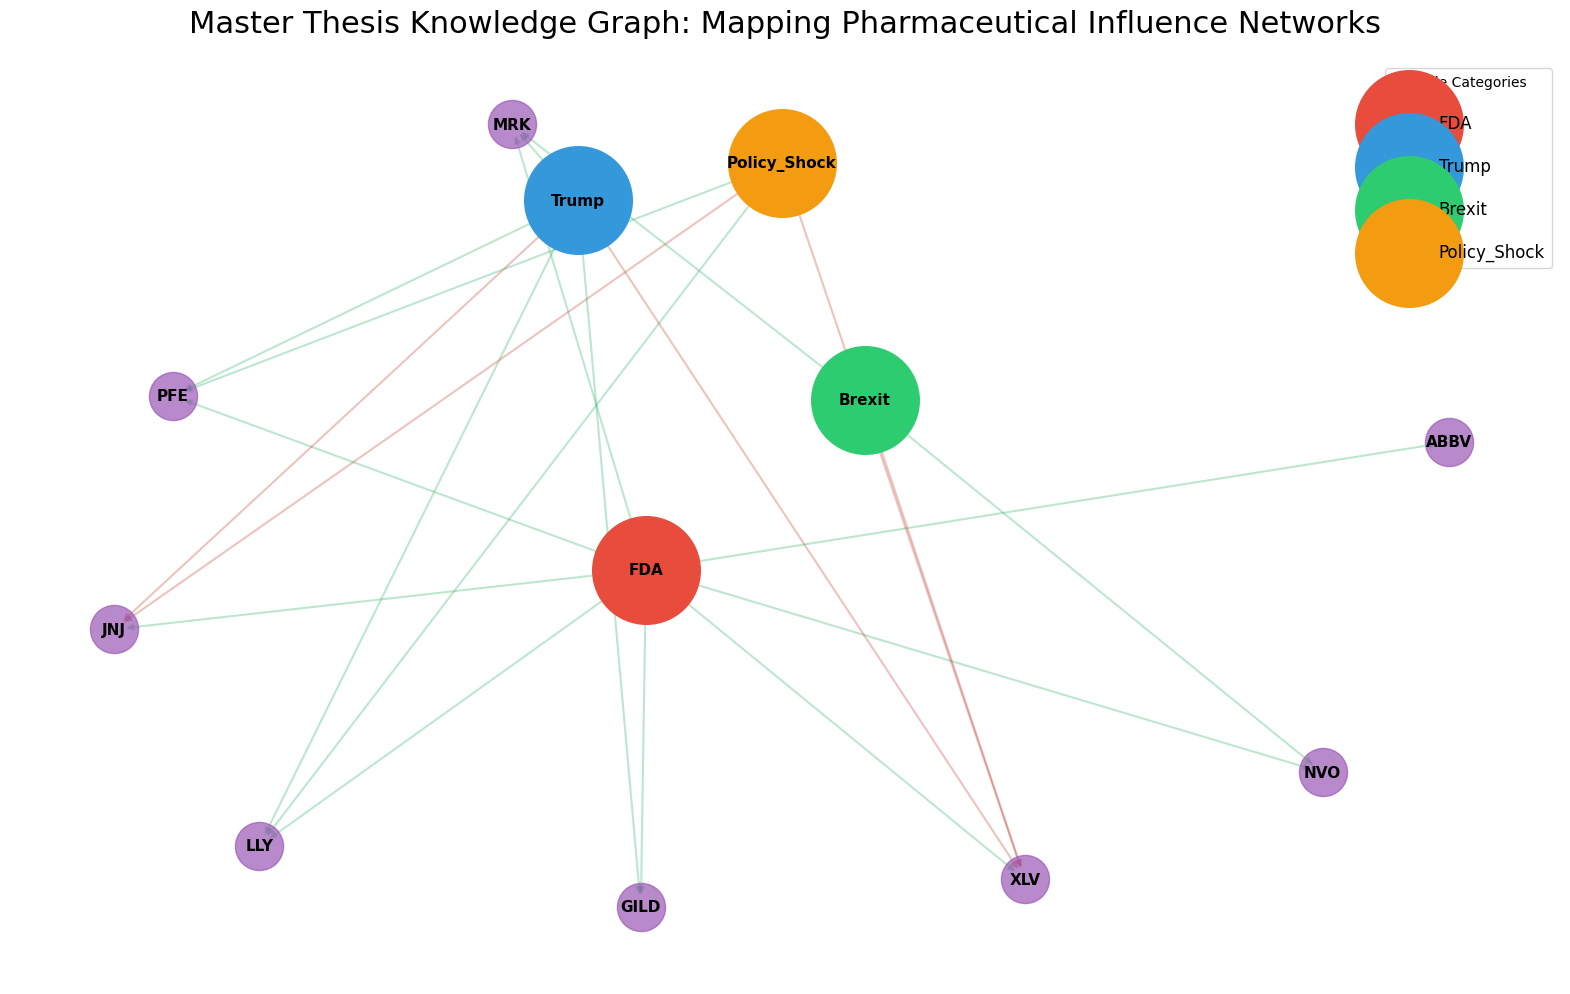

In [3]:

def plot_final_thesis_graph(G):
    plt.figure(figsize=(20, 12))

    hubs = ['FDA', 'Trump', 'Brexit', 'Policy_Shock']
    assets = [n for n in G.nodes() if n not in hubs]

    pos = nx.spring_layout(G, k=0.35, iterations=50, seed=42)

    hub_colors = {'FDA': '#e74c3c', 'Trump': '#3498db', 'Brexit': '#2ecc71', 'Policy_Shock': '#f39c12'}

    for hub in hubs:
        if G.has_node(hub):
            nx.draw_networkx_nodes(G, pos, nodelist=[hub],
                                   node_size=6000,
                                   node_color=hub_colors.get(hub, 'gray'),
                                   label=hub)

    nx.draw_networkx_nodes(G, pos, nodelist=assets,
                           node_size=1200,
                           node_color='#9b59b6',
                           alpha=0.7)

    for u, v, d in G.edges(data=True):
        edge_color = '#27ae60' if d['weight'] > 0 else '#c0392b'
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)],
                               width=1.5, alpha=0.3, edge_color=edge_color)


    nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold', font_color='black')

    plt.title("Master Thesis Knowledge Graph: Mapping Pharmaceutical Influence Networks", fontsize=22, pad=20)
    plt.legend(scatterpoints=1, labelspacing=1.5, title="Node Categories", fontsize=12)
    plt.axis('off')

    plt.savefig('Final_Thesis_Graph_Visualization.png', dpi=300, bbox_inches='tight')
    plt.show()


plot_final_thesis_graph(G)